# Tutorial 1: Fitting LC Models to a CPW 

In this tutorial, we will show you how to use the `simpleLOMs` package to fit an LC model to a distributed system. 

In this tutorial, we will fit a CPW element coupled on either side, with some coupling capacitance in series and to ground, to arbitrary $LC$ loads, representing qubits or other resonators.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

# lcfitter top-level imports
from simpleLOMs import CPWParams, FosterFit, OptimizedFit, AnalyticalFit, analyze_system

# Sub-module imports used in Section 2
from simpleLOMs.elements import coupling_capacitor, shunt_capacitor, lc_resonator
from simpleLOMs.networks.cpw import cpw_resonator_network_2port
from simpleLOMs.networks.lc import lc_resonator_network_2port, lc_resonator_network_with_grounds_2port
from simpleLOMs.analysis import resonance, fwhm_from_trace_db, resonances_from_s, resonance_from_s_max
from simpleLOMs.plotting import plot_re_im, plot_lom_vs_data_re_im, plot_all_models
from simpleLOMs.models.optimized_fit import OptimizationConfig

print("All imports OK")

All imports OK


---
## 1. Load your CPW

The CPW geometry lives in a `CPWParams` dataclass. It is defined once here and pass it into every function that needs it. 





In [2]:
cpw_params = CPWParams(
    w=11.7e-6,              # center conductor width (m)
    s=5.1e-6,               # gap spacing (m)
    t=0.0,                  # metal thickness — 0 = ideal thin film
    h=500e-6,               # substrate height (m)
    rho=1e-19,              # resistivity ≈ 0 → superconducting limit
    ep_r=11.45,             # relative permittivity (ultracold silicon)
    has_metal_backside=True,
    tand=0.0,               # lossless substrate
)

print(cpw_params) 

CPWParams(w=1.17e-05, s=5.1e-06, t=0.0, h=0.0005, rho=1e-19, ep_r=11.45, has_metal_backside=True, tand=0.0)


For this tutorial, we will provide values for the circuit-level parameters coupling capacitances. In practice, we reccomend extracting your `Cc1, Cc2, Ctog1, Ctog2` values by from Maxwell capacitance matricies from your EM solver of choice (eg. $\texttt{ANSYS HFSS, COMSOL}$). 

In [3]:
d     = 7.0e-3    # Resonator length (m). This system sets resonance near 8.5 GHz
Z0    = 10.0      # reference impedance in Ohms

Cc1   = 3.0e-14   # coupling capacitor, port 1 (F)
Cc2   = 7.0e-14   # coupling capacitor, port 2 (F)
Ctog1 = 4.0e-14   # shunt-to-ground cap, port 1 side (F)
Ctog2 = 6.0e-14   # shunt-to-ground cap, port 2 side (F)

We may also choose to define load resonators. This is not necessary for the initial fit, but allows us to determine the accuracy of the frequency shift that comes from this model

For this tutorial, we will choose two loads that are on the order of a typical qubit frequency ( around $3-5$ GHz).

In [4]:
Lload1 = 2e-09  # load 1 inductance (H)
Cload1 = 6.0e-13  # load 1 capacitance (F)
Lload2 = 4e-09  # load 2 inductance (H)
Cload2 = 6.0e-13  # load 2 capacitance (F)

# We can get the load's bare resonannce from the known LC formula.
f_load1 = 1.0 / (2 * np.pi * np.sqrt(Lload1 * Cload1)) / 1e9
f_load2 = 1.0 / (2 * np.pi * np.sqrt(Lload2 * Cload2)) / 1e9
print(f"Load 1 bare resonance: {f_load1:.4f} GHz")
print(f"Load 2 bare resonance: {f_load2:.4f} GHz")

Load 1 bare resonance: 4.5944 GHz
Load 2 bare resonance: 3.2487 GHz


We now define a coarse frequency spectrum that the system will later refine.

In [5]:
freq = rf.Frequency(6e9, 9e9, 400_001, unit="Hz")


### 1a. Inspect the CPW network

If you'd like, you can inspect the properties of the CPW network before performing the LC fit.

In [6]:
cpw_net = cpw_resonator_network_2port(
    freq, d, Cc1, Cc2, Ctog1, Ctog2,
    cpw_params=cpw_params, Z0=50,
)

# S11 resonance
f0_cpw_s11 = resonance(cpw_net, m=0, n=0)
f0_cpw_s22 = resonance(cpw_net, m=1, n=1)
f0_cpw_s12 = resonance(cpw_net, m=0, n=1)
f0_cpw_s21 = resonance(cpw_net, m=1, n=0)

k_cpw  = fwhm_from_trace_db(cpw_net, m=0, n=0, kind="dip")
print(f"CPW resonance (S11):  f0 = {f0_cpw_s11/1e9:.4f} GHz")
print(f"CPW resonance (S22):  f0 = {f0_cpw_s22/1e9:.4f} GHz")
print(f"CPW resonance (S12):  f0 = {f0_cpw_s12/1e9:.4f} GHz")
print(f"CPW resonance (S21):  f0 = {f0_cpw_s21/1e9:.4f} GHz")
print(f"CPW linewidth (S11):  κ  = {k_cpw/1e6:.4f} MHz")

CPW resonance (S11):  f0 = 7.4268 GHz
CPW resonance (S22):  f0 = 7.4212 GHz
CPW resonance (S12):  f0 = 8.1298 GHz
CPW resonance (S21):  f0 = 8.1298 GHz
CPW linewidth (S11):  κ  = 104.3107 MHz


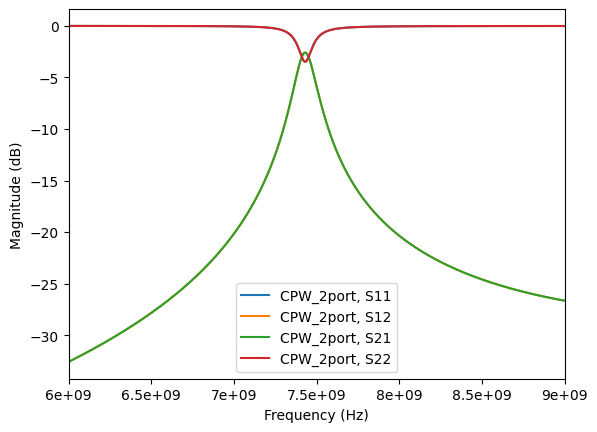

In [7]:
cpw_net.plot_s_db()

We can plot Re(S11) and Im(S11) to get a feel for the behavior of the CPW system.

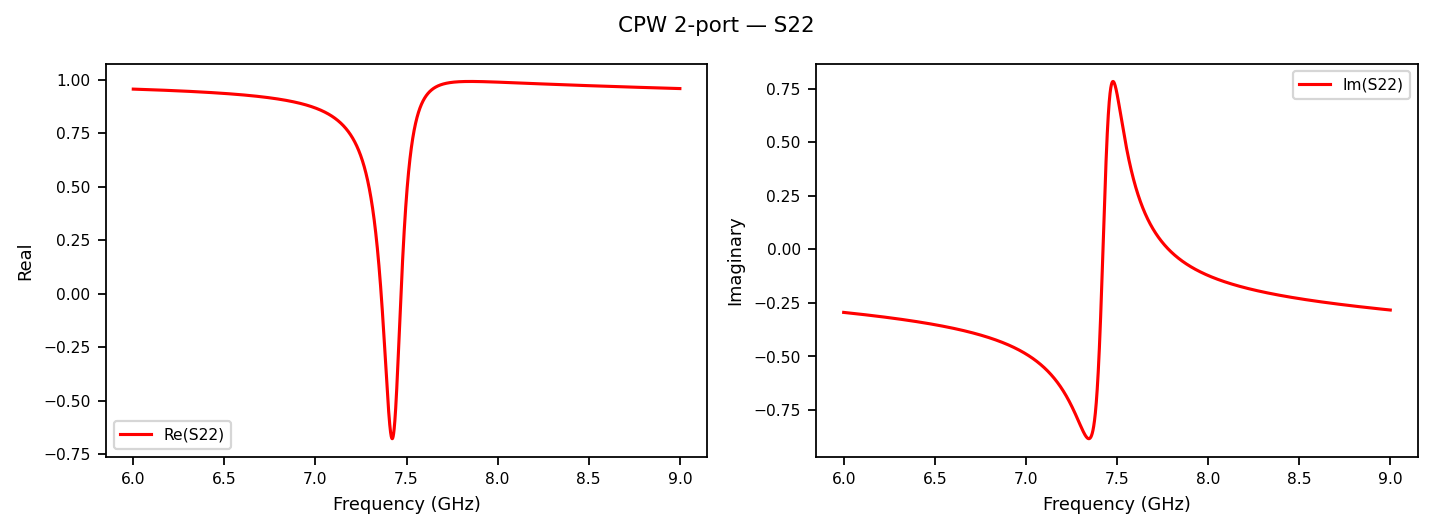

In [8]:
plot_re_im(cpw_net, m=1, n=1, title="CPW 2-port — S22")

We can find the resonance as measured from each port

In [9]:
f0_cpw_s11 = resonance(cpw_net, m=0, n=0)

f0_cpw_s12 = resonance_from_s_max(cpw_net, m=0, n=1)

print(f"CPW resonance (S11):  f0 = {f0_cpw_s11/1e9:.4f} GHz")
print(f"CPW resonance (S12):  f0 = {f0_cpw_s12/1e9:.4f} GHz")

CPW resonance (S11):  f0 = 7.4268 GHz
CPW resonance (S12):  f0 = 0.0000 GHz


---
## 3. Fitting Models Individually


The `simpleLOMs` package currently contains three primary fitting models;

1. `AnalyticalFit`,currently for $\lambda/2$ resonators only
2. `FosterFit` based on a Lossy Foster model (PhysRevLett.108.240502)
3.  `OptimizedFit`, our numerical model for extracting $L_{\mathrm{eff}}$ and $C_{\mathrm{eff}}$.

\\
Each model follows the same three-step pattern:
```python
model = ModelClass(...)   # 1. instantiate with configuration
model.fit(freq, ...)      # 2. run the fitting algorithm
net = model.get_network(refined_freq, ...)  # 3. build the fitted network
```


### 3a. AnalyticalFit

`AnalyticalFit` uses only two formulas:

1. $ C_{\mathrm{eff}} = \frac{\pi}{2 Z_0 \omega_{\lambda / 2}}$
2. $ L{\mathrm{eff}}  = \frac{1}{\omega_{\lambda / 2} C}$



 It includes no optimisation, or network simulation.
It requires an unloaded resonance frequency and a characteristic impedance $Z_0$. In practice, you can extract these from scikit-rf or TXLine.
If you do not supply `analytical_f_r`, `analyze_system` reads it from the CPW $S_{11}$ automatically.

In [10]:
# If you would like, you can choose a more refined frequency span centered around the resonant frequency.
refined_freq = rf.Frequency(f0_cpw_s11 - 0.5e9, f0_cpw_s11 + 0.5e9, 200_001, unit="Hz")

Here is an example of how to run the analytical fit. We set the mode equal to 2 for λ/2 resonator, which is the default value

You must also supply the CPW resonance frequency and the CPW characteristic impedance, both of which scikit-rf allows you to extract natively.

In [11]:
analytical = AnalyticalFit(mode=2)  # mode=2 for λ/2 resonator (default)

# Z0_cpw = 45.926 Ohms is the characteristic impedance of this particular CPW geometry
# in this case the frequency is the UNLOADED frequency, which for this particular case is 8.58 GHz.
Z0_cpw = 45.926
f0_unloaded = 8.58e9
analytical.fit(refined_freq, f_r=f0_unloaded, Z0=Z0_cpw)

print(analytical)
print(analytical.get_params())

AnalyticalFit(L=5.4234e-10 H, C=6.3445e-13 F, f_r=8.5800 GHz)
{'L': 5.423399393890448e-10, 'C': 6.344451756636576e-13, 'f_r_Hz': 8580000000.0, 'Z0': 45.926}


/Users/elizabeth/simpleLOMs/src/simpleLOMs/plotting.py:1054: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11, framealpha=0.9)


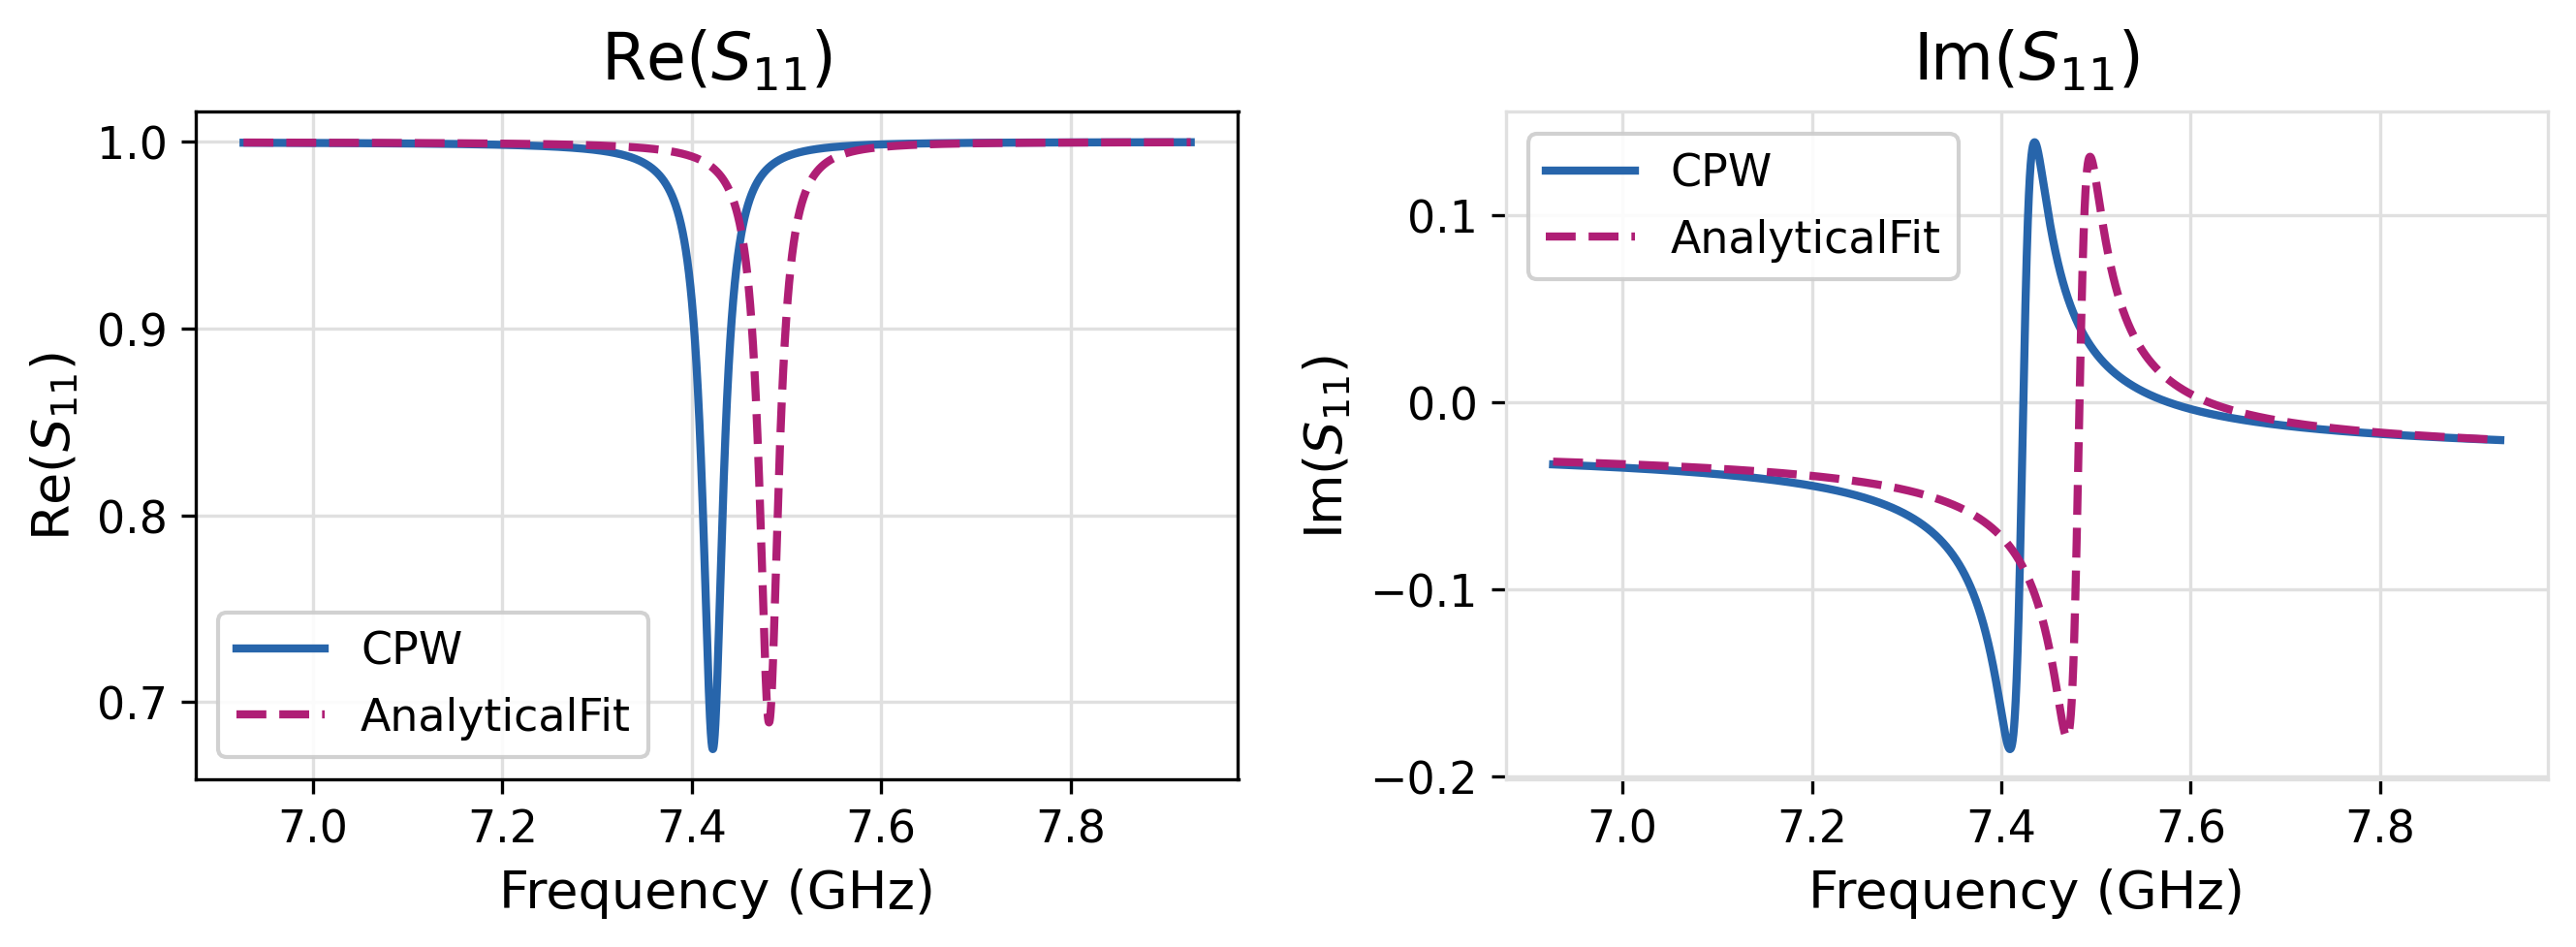

In [12]:
from simpleLOMs import plotting

analytical_net = analytical.get_network(
    refined_freq,
    Cc1=Cc1, Cc2=Cc2,
    Ctog1=Ctog1, Ctog2=Ctog2,
    Z0=Z0,
)

cpw_net_refined = cpw_resonator_network_2port(
    refined_freq, d, Cc1, Cc2, Ctog1, Ctog2,
    cpw_params=cpw_params, Z0=Z0,
)

plotting.fancy_plot(analytical_net, cpw_net_refined, m=0, n=0,
                       lom_label="AnalyticalFit", data_label="CPW")

In [13]:
from simpleLOMs import analysis 
f0_analytical = analysis.find_resonant_frequency(analytical_net)
k_analytical  = fwhm_from_trace_db(analytical_net, m=0, n=0, kind="dip")

print(f"Analytical  f0 = {f0_analytical/1e9:.4f} GHz   error = {abs(f0_analytical - f0_cpw_s21)/f0_cpw_s21*100:.3f}%")
print(f"Analytical  κ  = {k_analytical/1e6:.4f} MHz    error = {abs(k_analytical - k_cpw)/k_cpw*100:.3f}%")

Analytical  f0 = 7.4818 GHz   error = 7.971%
Analytical  κ  = 20.2577 MHz    error = 80.579%


### 3b. FosterFit

`FosterFit` extracts L and C from the admittance slope $\frac{dB}{d\omega}$ at the CPW resonance, $\omega_r$, following $\texttt{PhysRevLett.108.240502}$.

It only needs the resonator length `d` and the CPW geometry. No measured S-parameters are required.

In [14]:
foster = FosterFit(cpw_params=cpw_params)

# fit(): this part builds a bare CPW line (of length d) and runs the Foster synthesis
foster.fit(freq, d=d)

print(foster)                # takes the form of FosterFit(L=..., C=..., f0=... GHz)
print(foster.get_params())   # dict with L, C, f0_Hz

FosterFit(L=5.5278e-10 H, C=6.2211e-13 F, f0=8.5824 GHz)
{'L': 5.527845812867812e-10, 'C': 6.221138569987629e-13, 'f0_Hz': 8582370000.0}


We build a refined frequency grid around resonance, and rebuild + build the fitted Foster network on the refined grid, to get a closer sweep

In [15]:


foster_net = foster.get_network(
    refined_freq,
    Cc1=Cc1, Cc2=Cc2,
    Ctog1=Ctog1, Ctog2=Ctog2,
    Z0=Z0,
)

cpw_net_refined = cpw_resonator_network_2port(
    refined_freq, d, Cc1, Cc2, Ctog1, Ctog2,
    cpw_params=cpw_params, Z0=Z0,
)


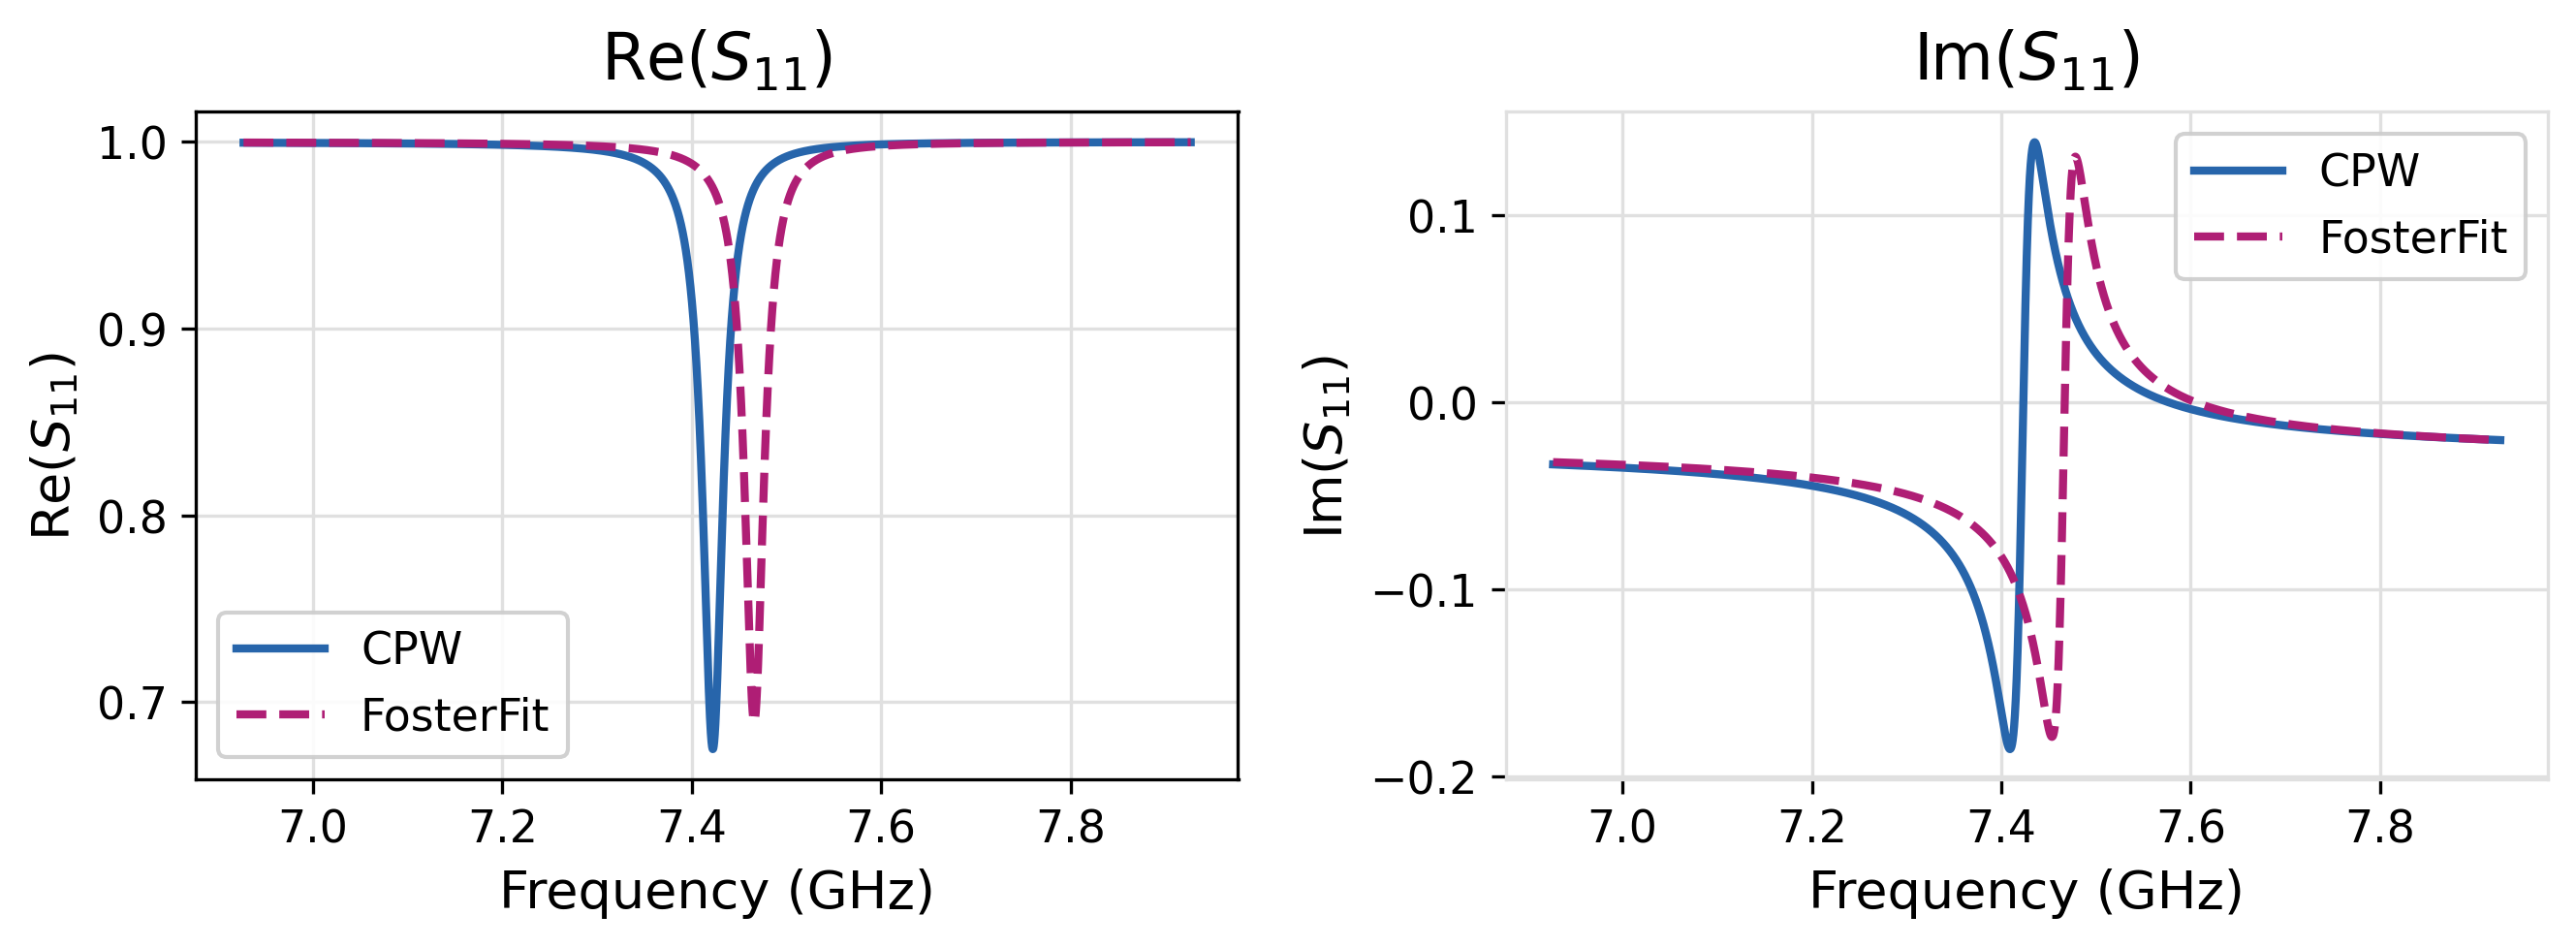

In [16]:
plotting.fancy_plot(foster_net, cpw_net_refined, m=0, n=0,
                       lom_label="FosterFit", data_label="CPW")

We can now compare the resultant $\omega$ and $\kappa$ of the final networks.

In [17]:
f0_foster = analysis.find_resonant_frequency(foster_net)
k_foster  = fwhm_from_trace_db(foster_net, m=0, n=0, kind="dip")

print(f"Foster  f0 = {f0_foster/1e9:.4f} GHz   error = {abs(f0_foster - f0_cpw_s21)/f0_cpw_s21*100:.3f}%")
print(f"Foster  κ  = {k_foster/1e6:.4f} MHz    error = {abs(k_foster - k_cpw)/k_cpw*100:.3f}%")

Foster  f0 = 7.4662 GHz   error = 8.163%
Foster  κ  = 20.4763 MHz    error = 80.370%


### 3c. OptimizedFit

`OptimizedFit` runs two stages of numerical optimisation against the CPW S11 and S22.
It needs the CPW network as input (or measured data — same interface).


The default parameters, in our experience, will nearly always outperform `FosterFit` and `AnalyticalFit`. However, in some cases, you may want to tune the parameters yourself. The `OptimizationConfig` class lets you tune the optimizer to your desired specifications. For example,

1. `w0_window_frac` scans circuits that produce \omega_0 to within a set percent. If you are most interested in producing *localized behavior at resonance*, we encourage setting `w0_window_frac` $\sim 0.0001$. However this can be relaxed to $\sim 0.005-0.05$ if you are most interested in producing *broadband behavior* across a wide spectrum of frequencies.
2. `n_w0` which provides a number of points within the specified range of the desired $\omega_0$ for an initial scan. As this initial guess will be refined later, we suggest setting `n_w0`$\sim 10-20$ to preserve runtime.
3. `n_dense` provides the number of points to optimize over for Stage 1. Again, we reccomend a value at or below $100$ to preserve runtime.
4. `n_widths` is the  window of points to optimize over in Stage 2, set to a range of linewidths. For example, `n_widths`=3 would represent a range of points centered at $\omega_r$ that span the range $\pm 3 \kappa$.


If you are most interested in producing *localized behavior at resonance*, we encourage setting `w0_window_frac` $\sim 0.0001$  and `n_widths`  $\sim 1$ . Alternatively, if you are most interested in producing *broadband behavior* across a wide spectrum of frequencies, we reccomend relaxing `w0_window_frac`and `n_widths`. 




In [18]:

config = OptimizationConfig(
    w0_window_frac=0.0001,  
    n_w0=5,              
    n_dense=10,           
    n_widths=3.0,         
    verbose=True,         
)

optimized = OptimizedFit(config=config)

cpw_net_refined = cpw_resonator_network_2port(
    refined_freq, d, Cc1, Cc2, Ctog1, Ctog2,
    cpw_params=cpw_params, Z0=Z0,
)


# fit() takes the CPW 2-port network as the reference
optimized.fit(refined_freq, data_ntw=cpw_net_refined, Cc1=Cc1, Cc2=Cc2,
              Ctog1=Ctog1, Ctog2=Ctog2, d=d, cpw_params=cpw_params, Z0=Z0)

print(optimized)
params = optimized.get_params()
print(f"L = {params['L']} H")
print(f"C = {params['C']:} F")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.0768e+00                                    5.54e+02    
       1              3         4.5932e+00      4.84e-01       1.75e-12       9.26e+02    
       2              4         3.8709e+00      7.22e-01       3.49e-12       3.82e+03    
       3              5         3.4238e+00      4.47e-01       1.10e-12       3.49e+02    
       4              7         3.0479e+00      3.76e-01       1.72e-12       9.66e+02    
       5              8         2.5286e+00      5.19e-01       3.42e-12       3.94e+03    
       6              9         2.1961e+00      3.32e-01       8.26e-13       2.12e+02    
       7             11         1.9188e+00      2.77e-01       1.69e-12       9.98e+02    
       8             12         1.5802e+00      3.39e-01       2.55e-12       2.33e+03    
       9             13         1.3831e+00      1.97e-01       1.03e-12       3.88e+02    

Get the network by running `optimized_net` with your desired parameters

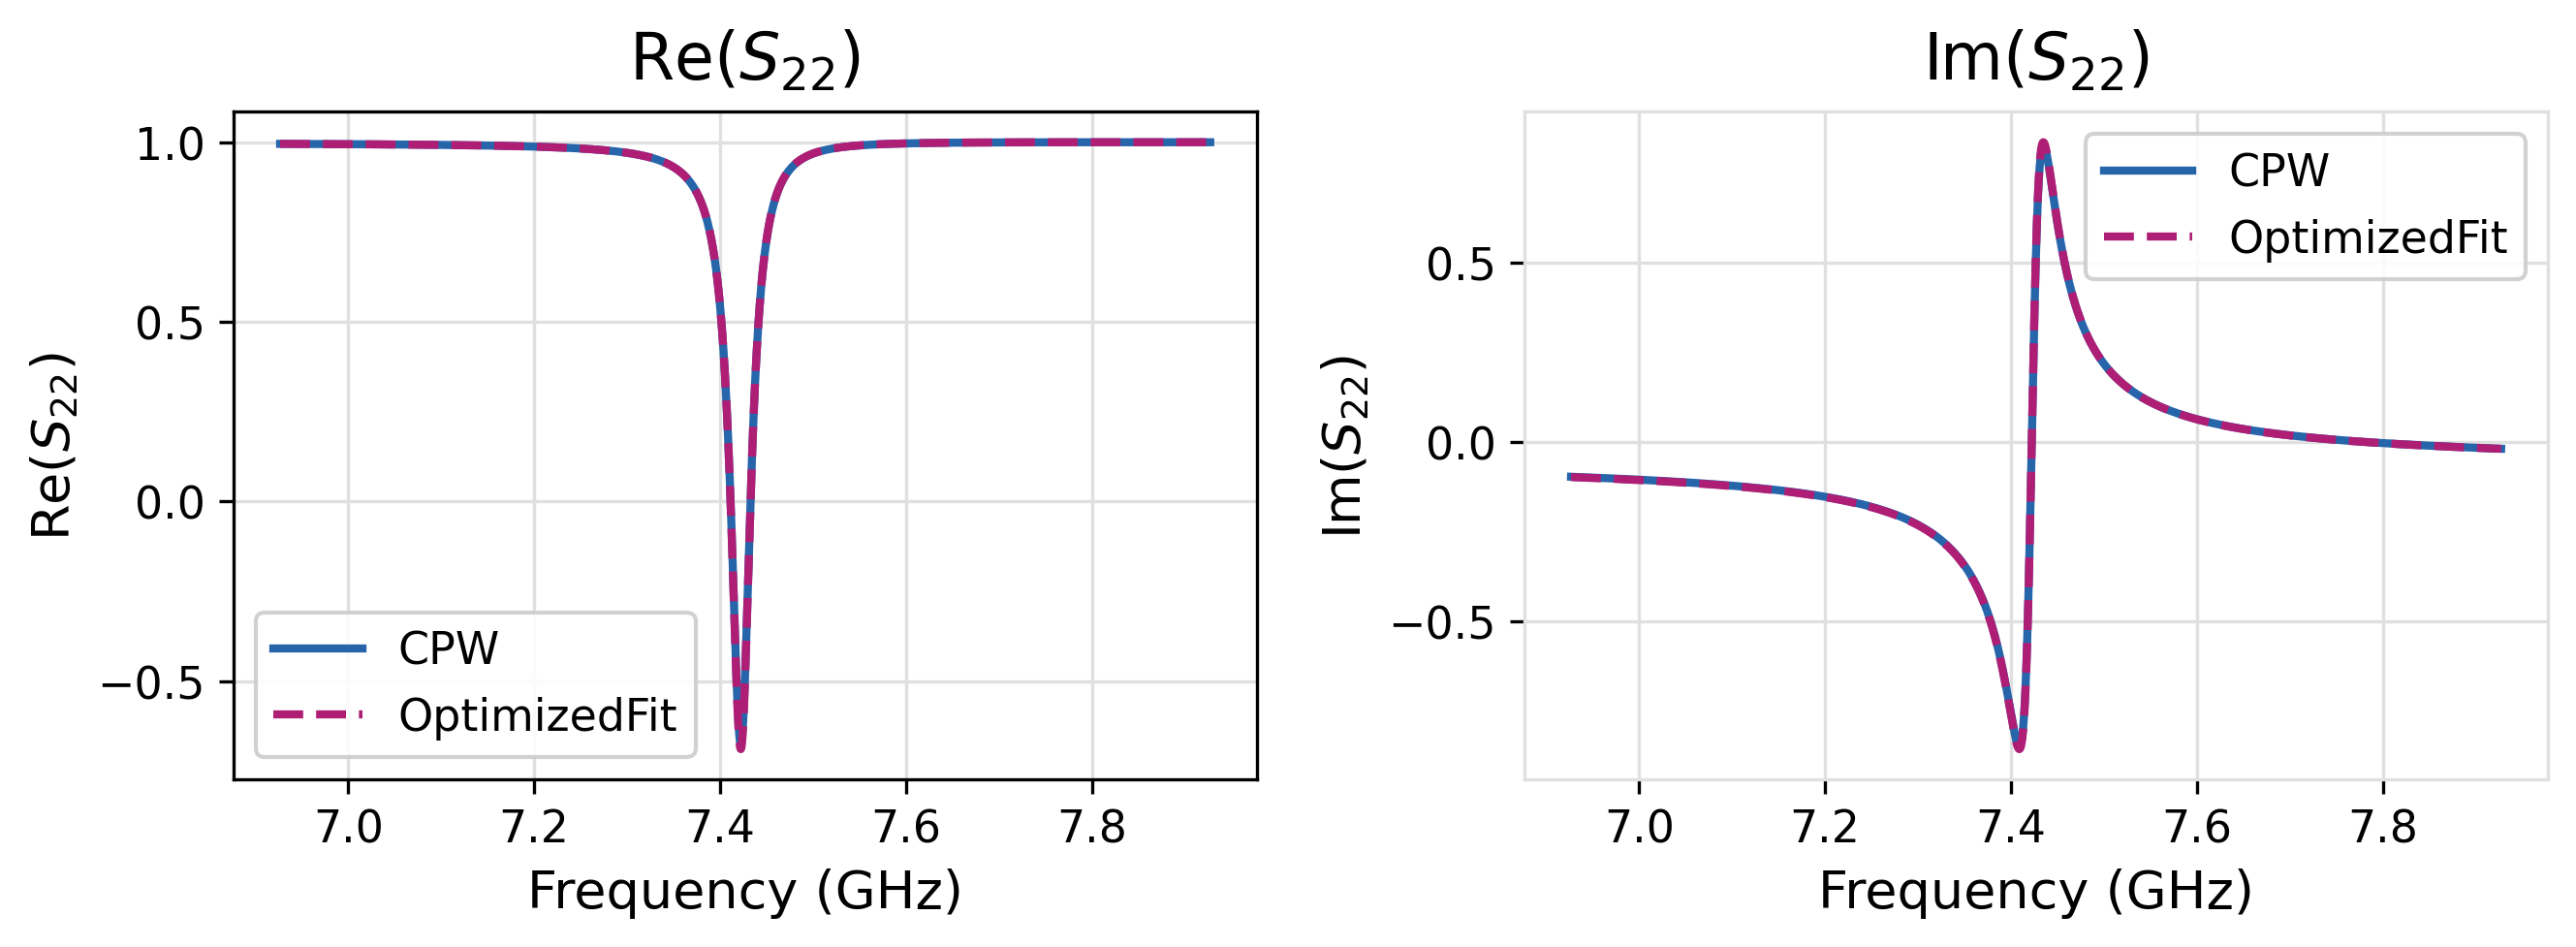

In [20]:
cpw_net_refined = cpw_resonator_network_2port(
    refined_freq, d, Cc1, Cc2, Ctog1, Ctog2,
    cpw_params=cpw_params, Z0=Z0,
)

optimized_net = optimized.get_network(
    refined_freq, Cc1=Cc1, Cc2=Cc2, Z0=Z0, 
)

plotting.fancy_plot(optimized_net, cpw_net_refined, m=1, n=1,
                       lom_label="OptimizedFit", data_label="CPW")

Return the final frequency and linewidth.

In [ ]:
f0_opt = plotting.find_resonant_frequency(optimized_net)
k_opt  = fwhm_from_trace_db(optimized_net, m=0, n=0, kind="dip")

print(f"Optimized  f0 = {f0_opt/1e9:.4f} GHz   error = {abs(f0_opt - f0_cpw_s11)/f0_cpw_s21*100:.3f}%")
print(f"Optimized  κ  = {k_opt/1e6:.4f} MHz    error = {abs(k_opt - k_cpw)/k_cpw*100:.3f}%")

Optimized  f0 = 7.5718 GHz   error = 0.023%
Optimized  κ  = 14.6007 MHz    error = 74.993%


You can also inspect the Stage 1 scan results to check that the optimizer found a clean minimum:

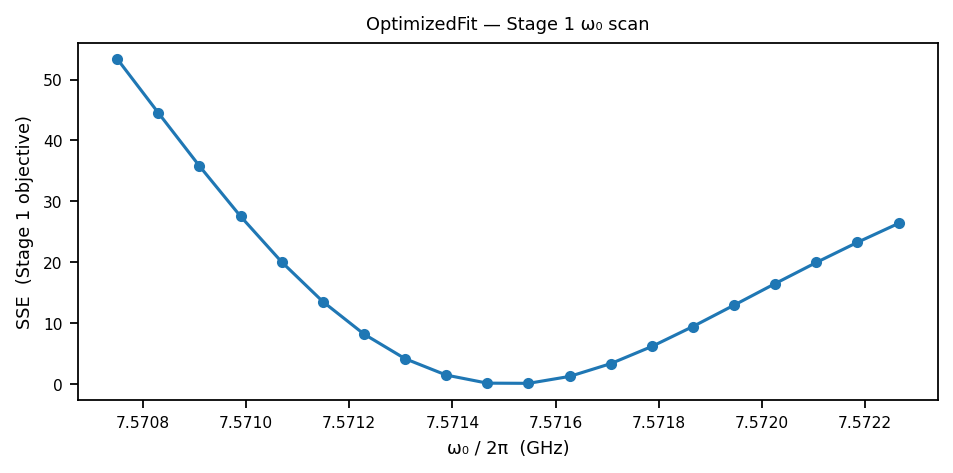

In [ ]:
scan = optimized.get_params()["scan_results"]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(scan[:, 0] / (2 * np.pi * 1e9), scan[:, 3], "o-", markersize=4)
ax.set_xlabel("ω₀ / 2π  (GHz)")
ax.set_ylabel("SSE  (Stage 1 objective)")
ax.set_title("OptimizedFit — Stage 1 ω₀ scan")
plt.tight_layout()
plt.show()

The optimized network uses $Re(S_{LOM} - S_{ref})$ as its residuals. To ensure that the optimizer worked as desired, you may plot the residuals for the scattering spectrum.

Saved: figures/residuals_s11.pdf


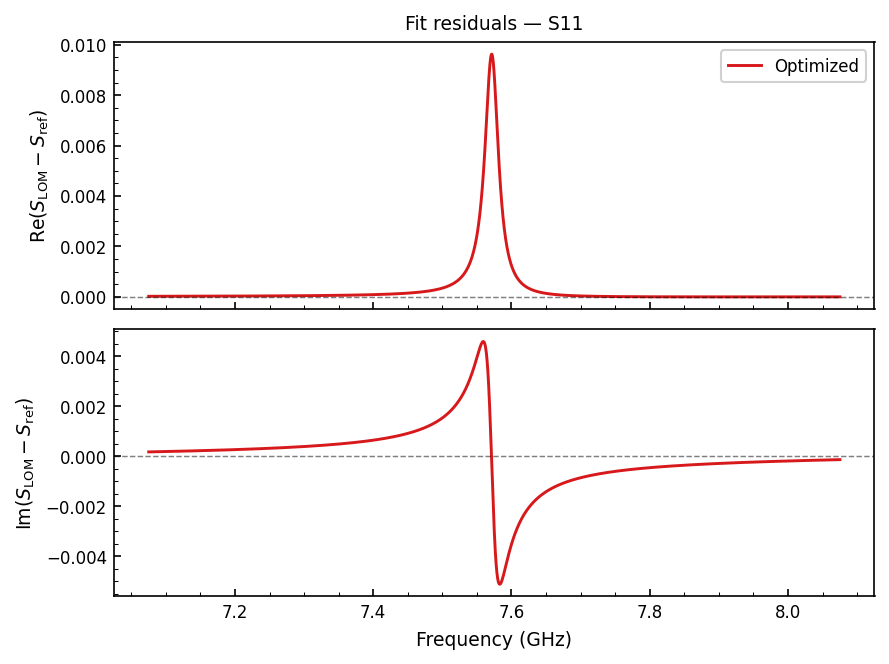

In [ ]:
from simpleLOMs import plotting

plotting.plot_fit_residuals(
    data_ntw    = cpw_net_refined,
    lom_networks = {
        "optimized":  optimized_net,
    },
    m=0, n=0,   # S11
    save_path="figures/residuals_s11.pdf",
)

### 3d. Side-by-side overlay

`plot_all_models` puts all four networks on one axes so you can visually rank the methods.

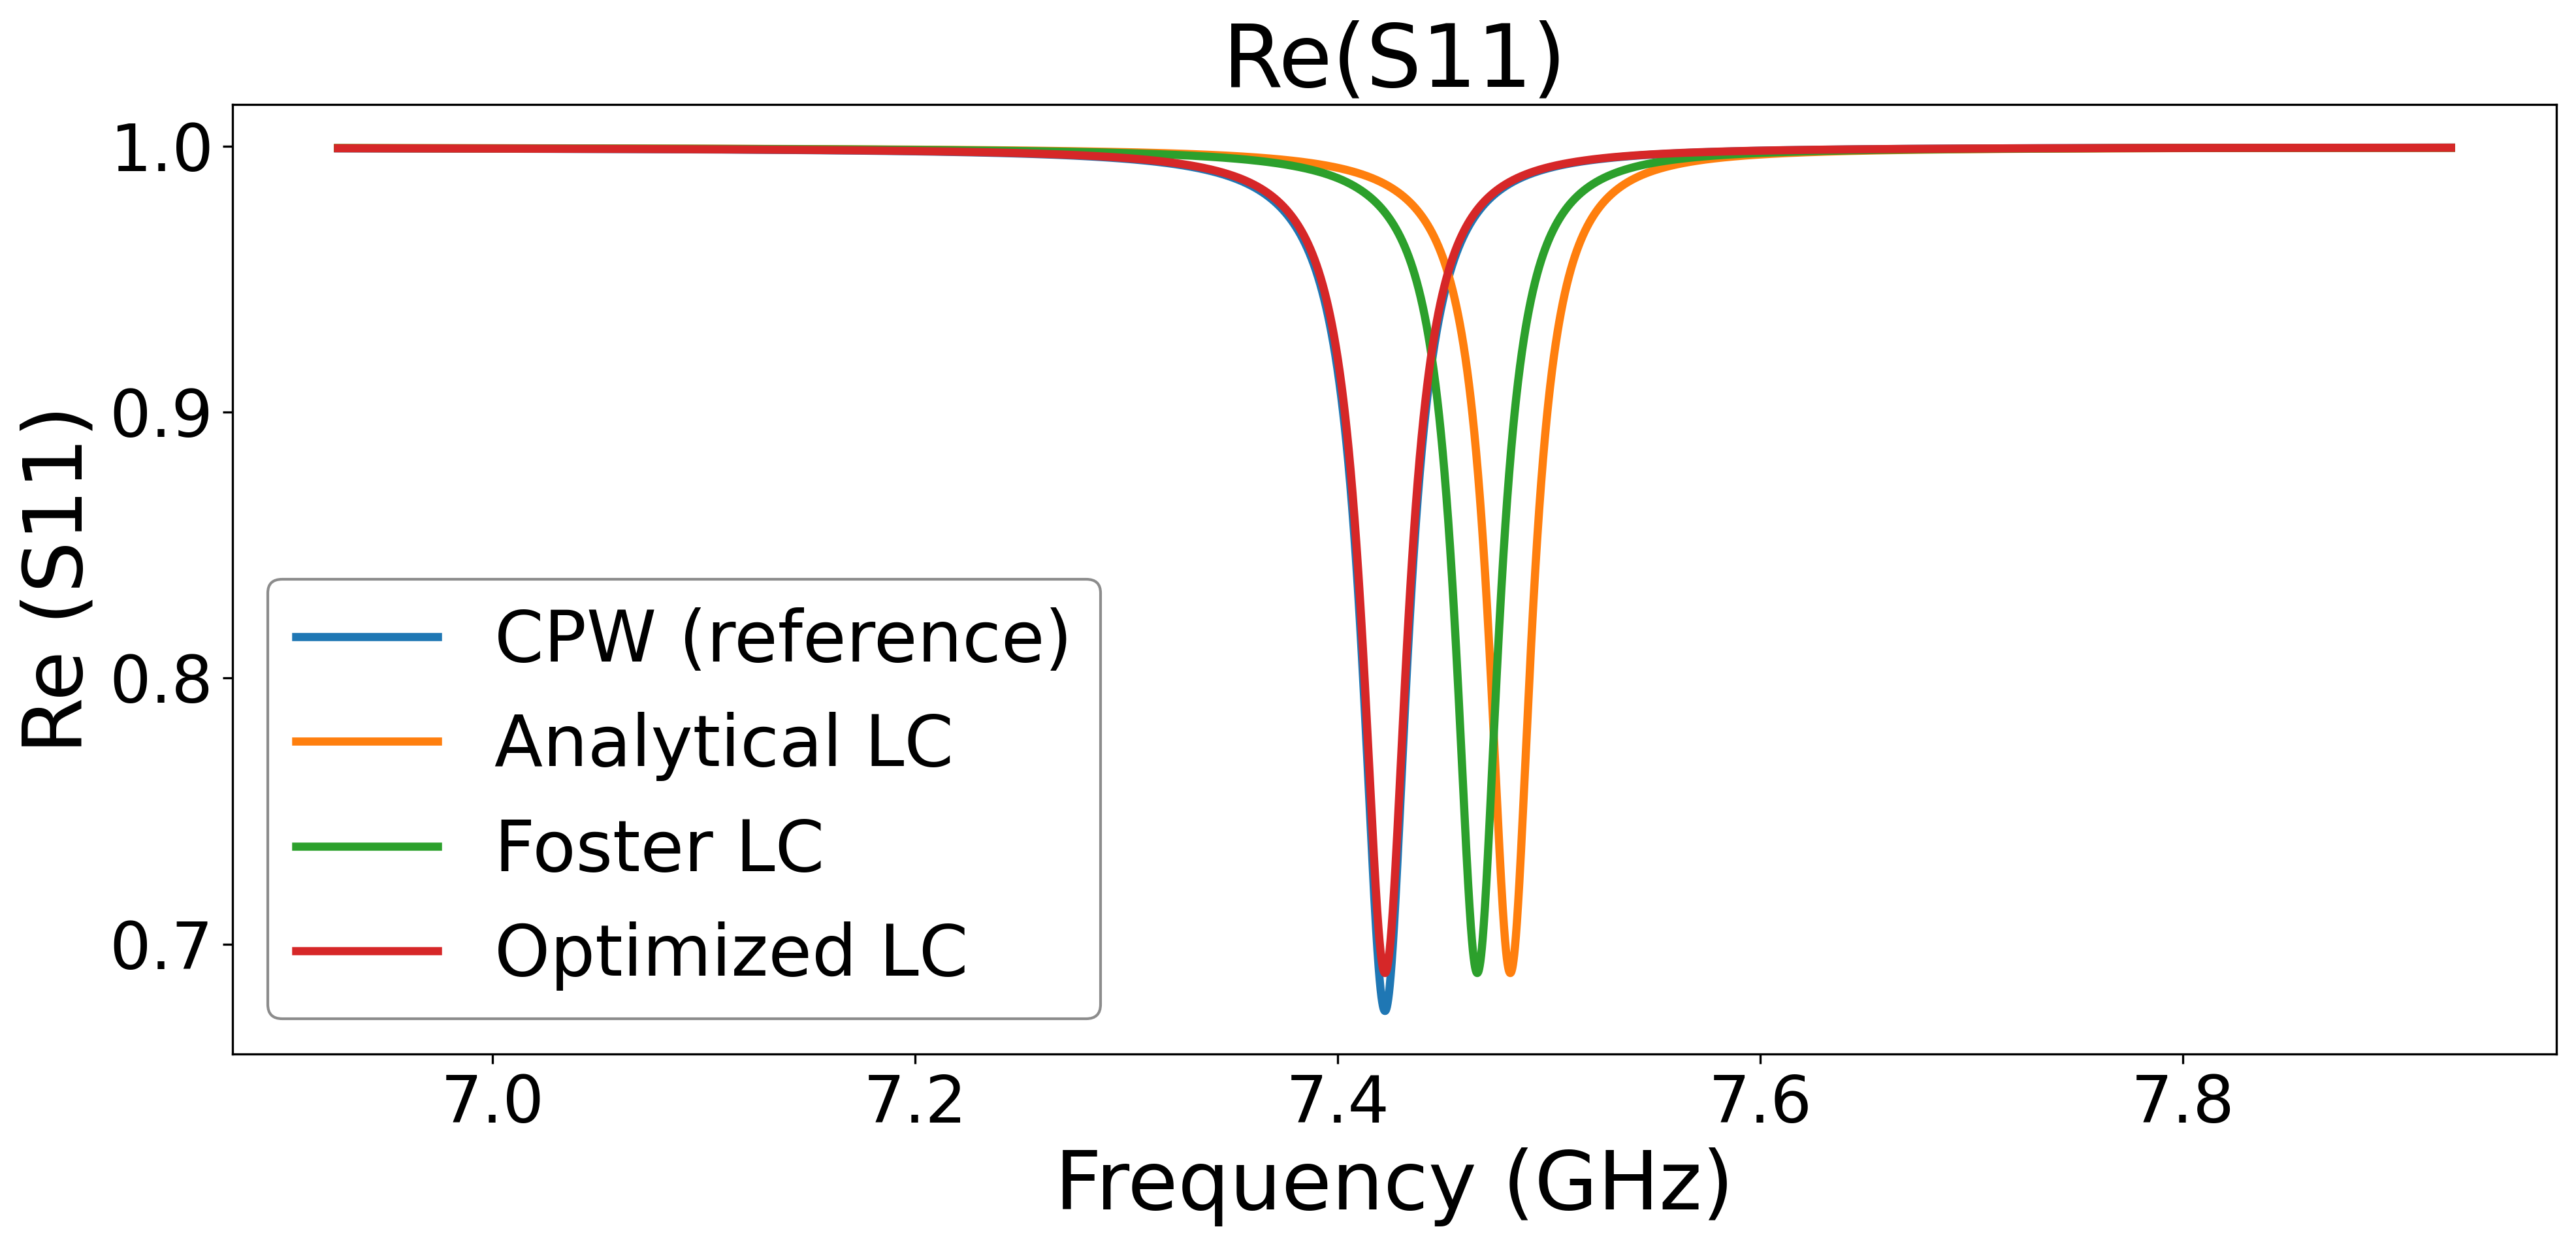

In [29]:
plotting.fancy_plot_all_models(
    {
        "CPW (reference)": cpw_net_refined,
        "Analytical LC":   analytical_net,
        "Foster LC":       foster_net,
         "Optimized LC":    optimized_net,
    },
    m=0, n=0,
    quantity="re",
    title="Re(S11)",
)

--- 
## 4. Full System Analysis

To compare all three methods, `analyze_system()` runs all three fitting methods, extracts resonances and linewidths
from $S_{11}$ and $S_{22}$, and builds a network with loads attached. It computes hybridized frequency shifts for the given loads and compares them to the CPW results. 

The returned `results` dict contains:
- The three fitted model objects (so you can get $L_{eff}$ and $C_{eff}$ for your desired method by  calling `.get_params()` etc. afterwards
- All resonance frequencies and linewidths with percent errors vs CPW
- Hybridised shifted frequencies and shift errors for the loaded system

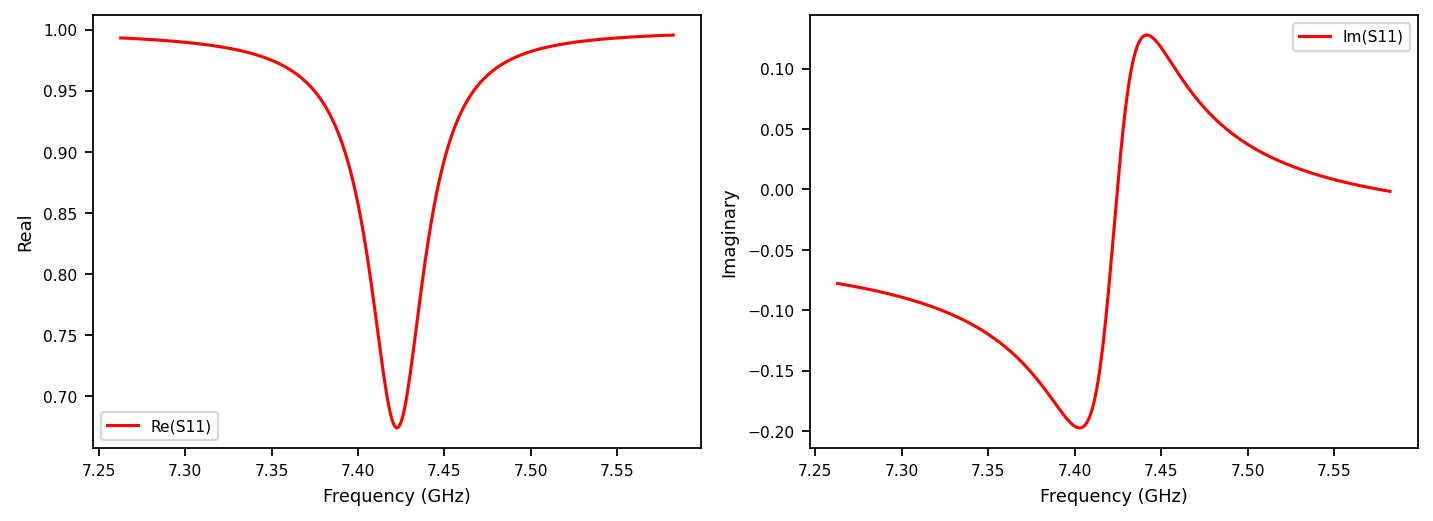

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.4387e+01                                    2.34e+03    
       1              2         2.3674e+01      7.12e-01       7.74e-12       3.83e+04    
       2              3         1.4345e+01      9.33e+00       4.46e-13       2.27e+02    
       3              4         1.2474e+01      1.87e+00       1.91e-12       2.36e+03    
       4              5         9.6838e+00      2.79e+00       3.75e-12       9.70e+03    
       5              6         8.1087e+00      1.58e+00       1.38e-12       1.28e+03    
       6              8         7.0467e+00      1.06e+00       1.53e-12       1.65e+03    
       7              9         5.4657e+00      1.58e+00       3.05e-12       6.85e+03    
       8             10         4.6053e+00      8.60e-01       1.25e-12       1.18e+03    
       9             11         3.9074e+00      6.98e-01       4.15e-12       1.34e+04    

In [31]:
freq = rf.Frequency(5e9, 10e9, 300_001, unit="Hz")

results = analyze_system(
    freq=freq,
    d=d,
    Cc1=Cc1,  Cc2=Cc2,
    Ctog1=Ctog1, Ctog2=Ctog2,
    # Lload1=Lload1, Cload1=Cload1,
    # Lload2=Lload2, Cload2=Cload2,
    cpw_params=cpw_params,
    Z0=15, # the REFERENCE impedance
    analytical_Z0=45.926, #  the CPW characteristic impedance (for the AnalyticalFit formula)
    verbose=True,
)

print("analyze_system() complete.")
print("Result keys:", [k for k in results if not isinstance(results[k], (rf.Network, FosterFit, OptimizedFit, AnalyticalFit))])

### 4a. View results as tables

In [32]:
from simpleLOMs import utils
utils.make_results_table(results)

,f0 S11 (GHz),κ S11 (MHz),f0 S22 (GHz),κ S22 (MHz),f0 error S11 (%),κ error S11 (%),f0 error S22 (%),κ error S22 (%)
Method,,,,,,,,
CPW,7.4226,31.2569,7.4220,31.2569,NaN,NaN,NaN,NaN
Optimized,7.4226,31.3582,7.4221,31.3582,0.0005,0.3241,0.0001,0.3241
Foster,7.4663,29.7962,7.4657,29.7962,0.5886,4.6730,0.5886,4.6730
Analytical,7.4819,29.3575,7.4814,29.3575,0.7991,6.0767,0.7992,6.0767


In [33]:
utils.make_params_table(results)

,L (H),C (F)
Model,,
Foster,5.527729e-10,6.221275e-13
Optimized,5.911714e-10,6.778010e-13
Analytical,5.423399e-10,6.344452e-13


### 4b. Plotting the results

The `results` dict stores the fitted network objects so you can plot without rerunning anything.

Saved: figures/fit_summary.pdf


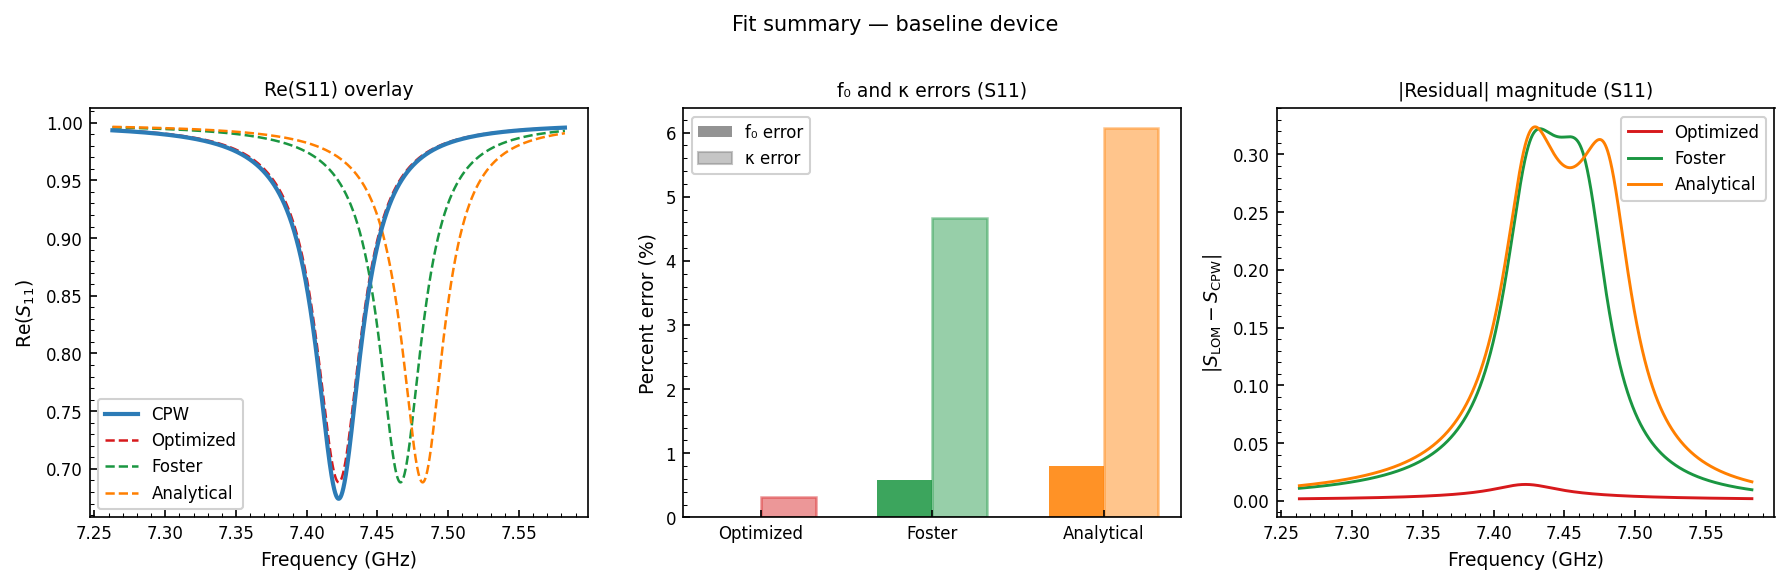

In [34]:
from simpleLOMs import plotting
plotting.plot_fit_summary(
    results,
    port="s11",
    title="Fit summary — baseline device",
    save_path="figures/fit_summary.pdf",
)

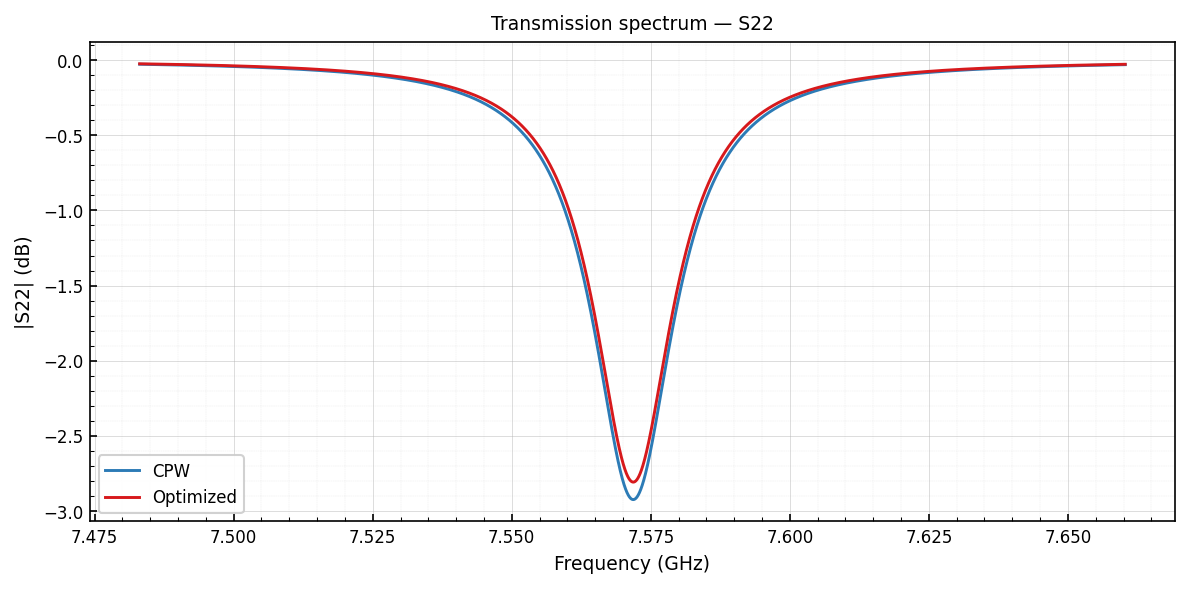

In [ ]:
plotting.plot_transmission_spectrum(
    networks={
        "cpw":       results["cpw_network"],
        "optimized": results["optimized_network"],
    },
    m=1, n=1
)

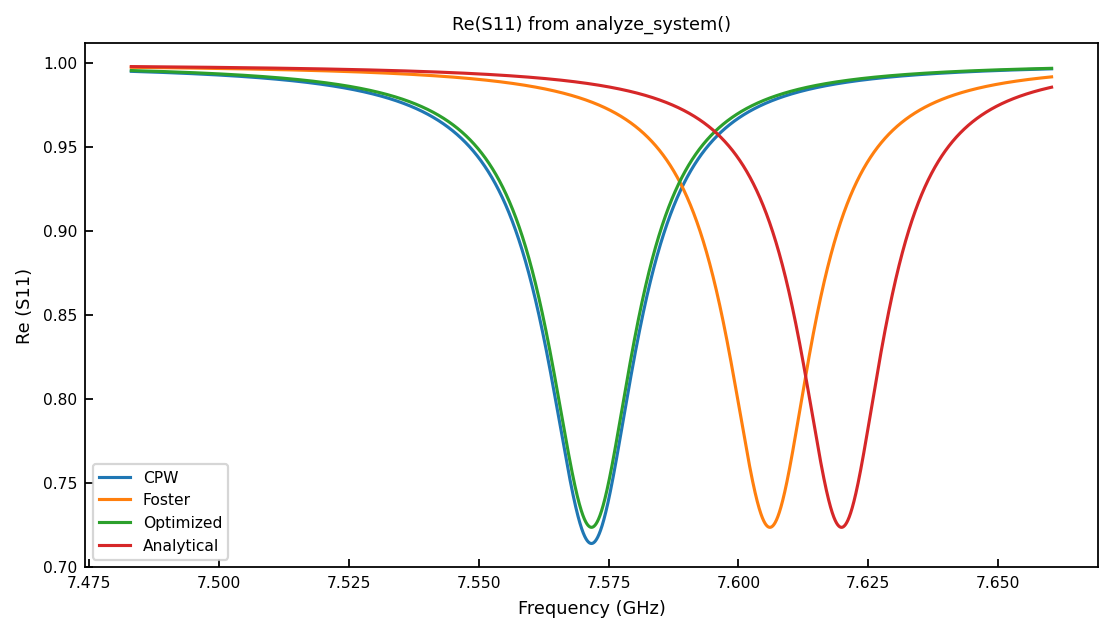

In [ ]:
plot_all_models(
    {
        "CPW":          results["cpw_network"],
        "Foster":       results["foster_network"],
        "Optimized":    results["optimized_network"],
        "Analytical":   results["analytical_network"],
    },
    m=0, n=0,
    quantity="re",
    title="Re(S11) from analyze_system()",
)

### 4b. Extrating the final model's parameters

In order to get the model parameters generated by each model, you can call `.get_params()` on any of the models to get $L_{eff}$ and $C_{eff}$ for your desired method.

In [ ]:

foster_model     = results["foster_model"]
analytical_model = results["analytical_model"]


print(foster_model.get_params())
print(analytical_model.get_params())

{'L': 5.527728992684269e-10, 'C': 6.221274876932394e-13, 'f0_Hz': 8582366666.666667}
{'L': 5.423399393890448e-10, 'C': 6.344451756636576e-13, 'f_r_Hz': 8580000000.0, 'Z0': 45.926}
